In [ ]:
from google.colab import files
files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
! pip install -q kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 95% 626M/658M [00:11<00:00, 60.3MB/s]
100% 658M/658M [00:11<00:00, 61.3MB/s]


In [ ]:
!ls -lrth

total 658M
-rw-r--r-- 1 root root 658M Oct 10  2019 plantdisease.zip
drwxr-xr-x 1 root root 4.0K Dec  9 14:42 sample_data
-rw-r--r-- 1 root root   69 Jan 19 15:13 kaggle.json


In [ ]:
!unzip plantdisease.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

In [ ]:
!ls -lrth PlantVillage/

total 2.1M
drwxr-xr-x 2 root root 104K Jan 19 15:19 Pepper__bell___Bacterial_spot
drwxr-xr-x 2 root root 132K Jan 19 15:19 Pepper__bell___healthy
drwxr-xr-x 2 root root 104K Jan 19 15:19 Potato___Early_blight
drwxr-xr-x 2 root root 100K Jan 19 15:19 Potato___Late_blight
drwxr-xr-x 2 root root  20K Jan 19 15:19 Potato___healthy
drwxr-xr-x 2 root root 228K Jan 19 15:19 Tomato_Bacterial_spot
drwxr-xr-x 2 root root 100K Jan 19 15:19 Tomato_Early_blight
drwxr-xr-x 2 root root 204K Jan 19 15:19 Tomato_Late_blight
drwxr-xr-x 2 root root  92K Jan 19 15:19 Tomato_Leaf_Mold
drwxr-xr-x 2 root root 180K Jan 19 15:19 Tomato_Septoria_leaf_spot
drwxr-xr-x 2 root root 164K Jan 19 15:19 Tomato_Spider_mites_Two_spotted_spider_mite
drwxr-xr-x 2 root root 136K Jan 19 15:19 Tomato__Target_Spot
drwxr-xr-x 2 root root 304K Jan 19 15:19 Tomato__Tomato_YellowLeaf__Curl_Virus
drwxr-xr-x 2 root root  36K Jan 19 15:19 Tomato__Tomato_mosaic_virus
drwxr-xr-x 2 root root 148K Jan 19 15:19 Tomato_healthy


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [ ]:
imgs_path='PlantVillage/'
img_size=84
batch_size=64


In [ ]:
class_names = os.listdir(imgs_path)
class_names

['Tomato_Septoria_leaf_spot',
 'Tomato_Early_blight',
 'Pepper__bell___healthy',
 'Potato___healthy',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato_Leaf_Mold',
 'Potato___Early_blight',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy',
 'Tomato__Target_Spot',
 'Potato___Late_blight',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato_Late_blight',
 'Pepper__bell___Bacterial_spot',
 'Tomato_Bacterial_spot']

In [ ]:

def get_data(data_dir):
    img_data = []
    labels=[]
    for label in class_names:
        path = os.path.join(data_dir, label)
        class_num = class_names.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                resized_arr = cv2.resize(img_arr, (img_size, img_size)) # Reshaping images to preferred size
                img_data.append(resized_arr)
                labels.append(class_num)
            except Exception as e:
                print(e)
    return np.array(img_data),np.array(labels)

In [ ]:
img_data,labels = get_data(imgs_path)
print(f'the shape of input image data is {img_data.shape}, labels shape is {labels.shape}')

OpenCV(4.12.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'

the shape of input image data is (20638, 84, 84, 3), labels shape is (20638,)


[Text(0, 0, 'Tomato_Septoria_leaf_spot'),
 Text(1, 0, 'Tomato_Early_blight'),
 Text(2, 0, 'Pepper__bell___healthy'),
 Text(3, 0, 'Potato___healthy'),
 Text(4, 0, 'Tomato_Spider_mites_Two_spotted_spider_mite'),
 Text(5, 0, 'Tomato_Leaf_Mold'),
 Text(6, 0, 'Potato___Early_blight'),
 Text(7, 0, 'Tomato__Tomato_mosaic_virus'),
 Text(8, 0, 'Tomato_healthy'),
 Text(9, 0, 'Tomato__Target_Spot'),
 Text(10, 0, 'Potato___Late_blight'),
 Text(11, 0, 'Tomato__Tomato_YellowLeaf__Curl_Virus'),
 Text(12, 0, 'Tomato_Late_blight'),
 Text(13, 0, 'Pepper__bell___Bacterial_spot'),
 Text(14, 0, 'Tomato_Bacterial_spot'),
 Text(15, 0, ''),
 Text(16, 0, ''),
 Text(17, 0, ''),
 Text(18, 0, ''),
 Text(19, 0, ''),
 Text(20, 0, ''),
 Text(21, 0, ''),
 Text(22, 0, ''),
 Text(23, 0, ''),
 Text(24, 0, ''),
 Text(25, 0, ''),
 Text(26, 0, ''),
 Text(27, 0, ''),
 Text(28, 0, ''),
 Text(29, 0, ''),
 Text(30, 0, ''),
 Text(31, 0, ''),
 Text(32, 0, ''),
 Text(33, 0, ''),
 Text(34, 0, ''),
 Text(35, 0, ''),
 Text(36, 0, ''

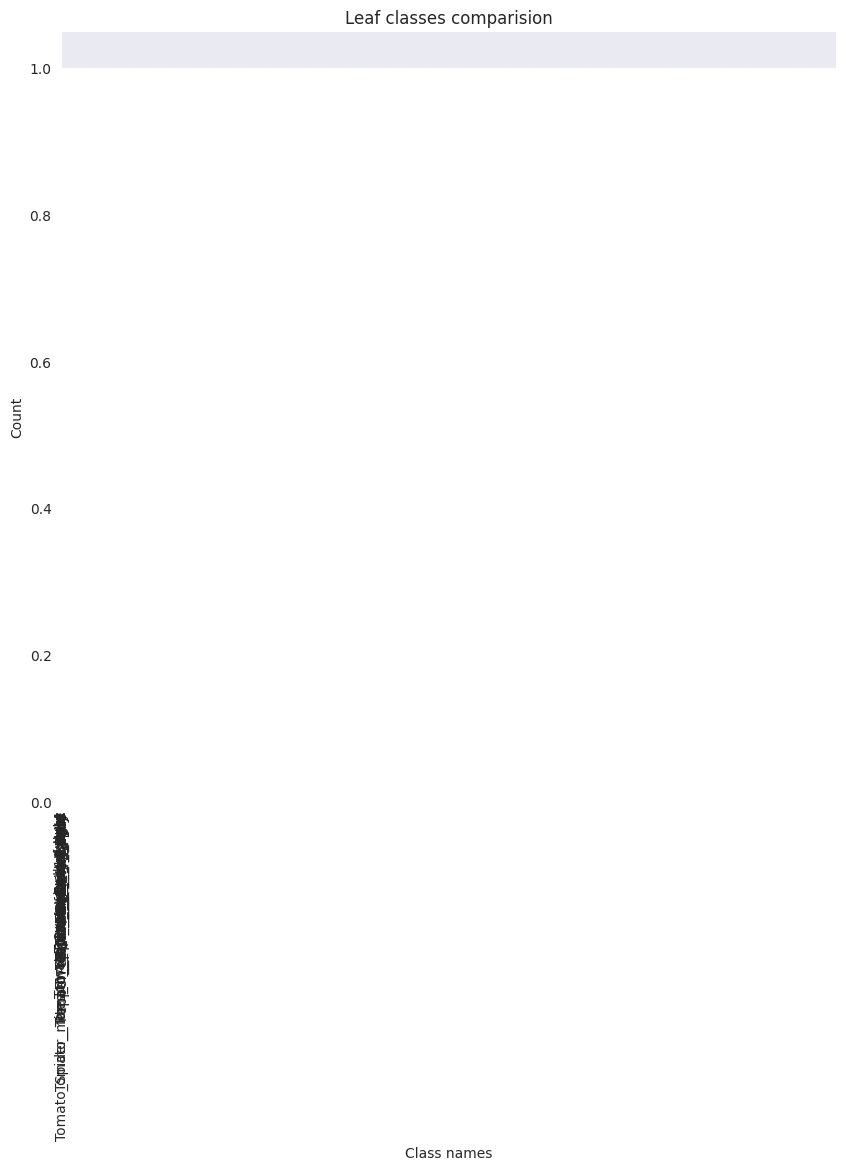

In [ ]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111)
sns.set_style('dark')
sns.countplot(labels)
plt.title('Leaf classes comparision')
plt.xlabel('Class names')
plt.ylabel('Count')
ax.set_xticklabels(class_names,rotation=90)

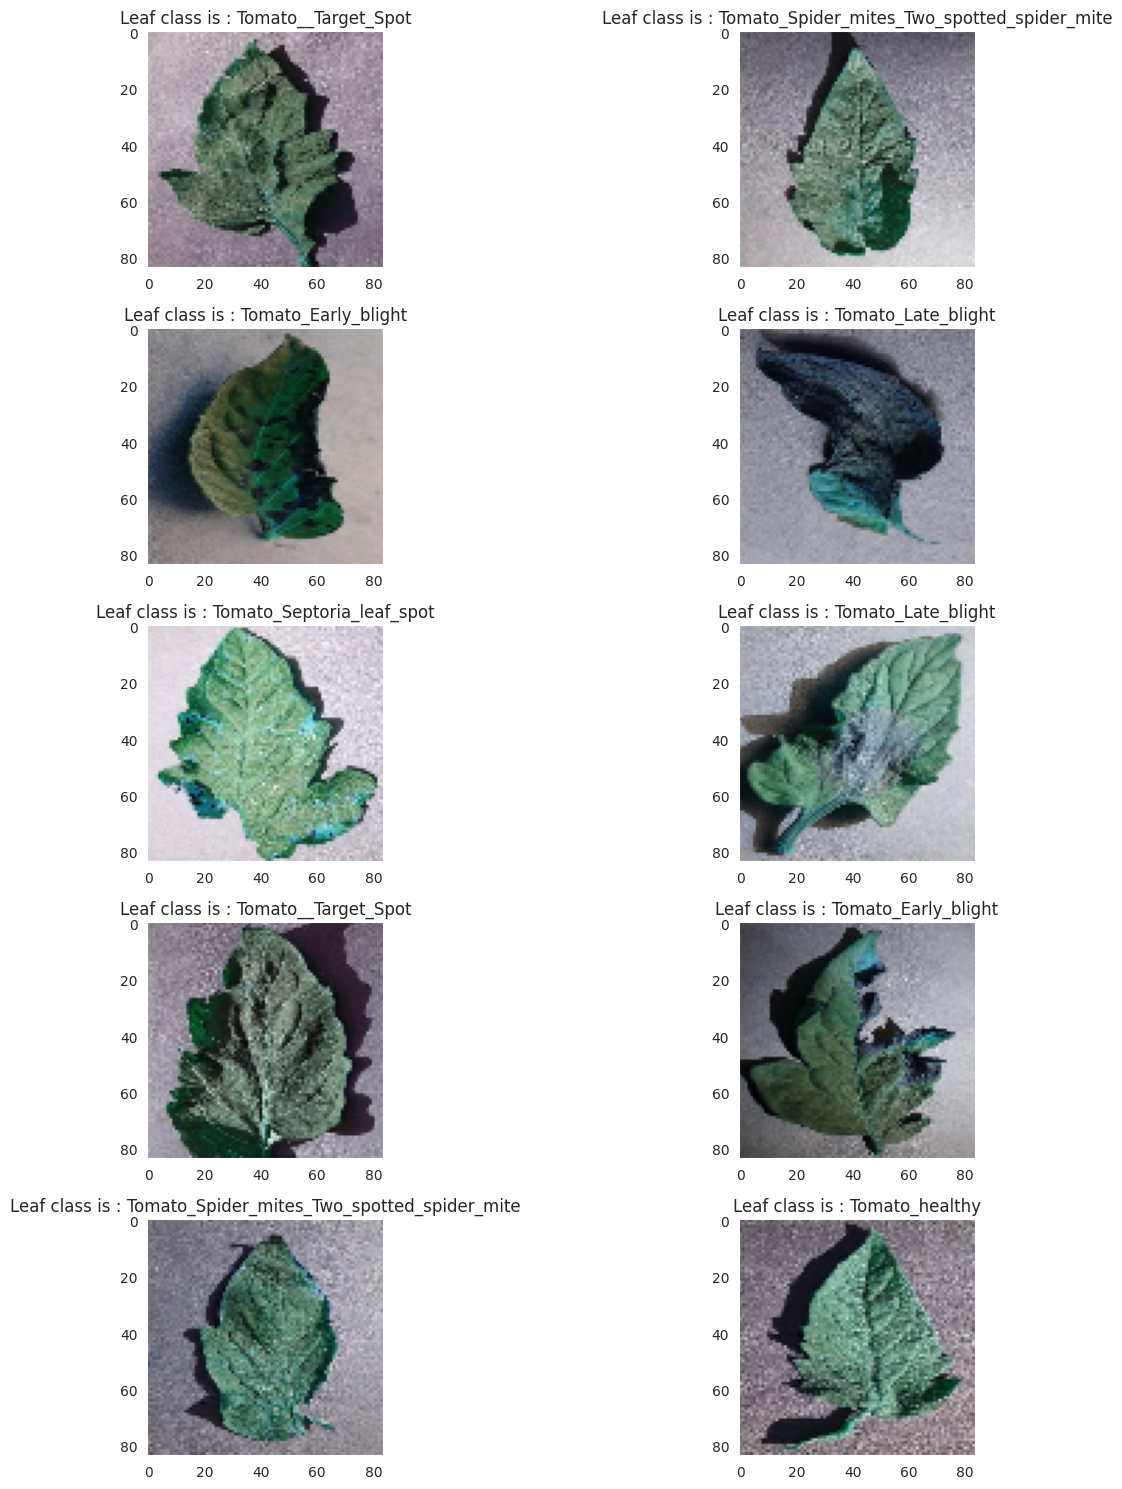

In [ ]:
fig,ax=plt.subplots(5,2)
fig.set_size_inches(15,15)
for i in range(5):
    for j in range (2):
        l=random.randint(0,len(img_data))
        ax[i,j].imshow(img_data[l])
        ax[i,j].set_title('Leaf class is : '+str(class_names[labels[l]]))

plt.tight_layout()

In [ ]:
from tensorflow.keras.applications.inception_v3 import preprocess_input
img_data=preprocess_input(img_data)
img_data[0]

array([[[ 0.37254906,  0.12156868,  0.16078436],
        [ 0.36470592,  0.11372554,  0.15294123],
        [ 0.4039216 ,  0.15294123,  0.19215691],
        ...,
        [ 0.41176474,  0.1686275 ,  0.2313726 ],
        [ 0.3803922 ,  0.13725495,  0.19215691],
        [ 0.32549024,  0.082353  ,  0.13725495]],

       [[ 0.3803922 ,  0.12941182,  0.1686275 ],
        [ 0.4039216 ,  0.15294123,  0.19215691],
        [ 0.38823533,  0.13725495,  0.17647064],
        ...,
        [ 0.4431373 ,  0.20000005,  0.254902  ],
        [ 0.43529415,  0.19215691,  0.24705887],
        [ 0.4039216 ,  0.16078436,  0.21568632]],

       [[ 0.3803922 ,  0.12941182,  0.1686275 ],
        [ 0.43529415,  0.18431377,  0.22352946],
        [ 0.3803922 ,  0.12941182,  0.1686275 ],
        ...,
        [ 0.49803925,  0.254902  ,  0.30980396],
        [ 0.39607847,  0.15294123,  0.20784318],
        [ 0.38823533,  0.14509809,  0.20000005]],

       ...,

       [[ 0.48235297,  0.2941177 ,  0.37254906],
        [ 0

In [ ]:
from tensorflow.keras.utils import to_categorical
labels=to_categorical(labels)
labels[0]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(img_data,labels,test_size=0.2,random_state=0,stratify=labels)
print(f'X_train size is {X_train.shape}, X_test shape is {X_test.shape}')

In [ ]:
del img_data,labels

**Implementing using VGG19**

In [ ]:
from tensorflow.keras.layers import *

from tensorflow.keras.models import *

In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19
vgg = VGG19(input_shape=(img_size,img_size,3), include_top=False, weights="imagenet")

for layer in vgg.layers[:19]:
        layer.trainable = False

model2=Sequential()
model2.add(vgg)
model2.add(MaxPool2D((2,2),strides=(2,2)))
model2.add(Flatten())
model2.add(Dense(len(class_names),activation='softmax'))
model2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model2.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 2, 2, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,032,079 (76.42 MB)

 Trainable params: 4,727,311 (18.03 MB)

 Non-trainable params: 15,304,768 (58.38 MB)

In [ ]:
history2=model2.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=batch_size)

In [ ]:
plt.figure(figsize=[8,6])
plt.plot(history2.history['accuracy'],'r',linewidth=2.0)
plt.plot(history2.history['val_accuracy'],'b',linewidth=2.0)
plt.legend(['Training accuracy', 'Validation accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('accuracy',fontsize=16)
plt.title('val accuracy',fontsize=16)

In [ ]:
vgg_acc=model2.evaluate(X_test,y_test)
print('accuracy of the model is ',vgg_acc[1])

**For testing the external image**

In [ ]:
from google.colab import files
files.upload()

In [ ]:
#image_name='PlantVillage/Potato___healthy/03da9931-e514-4cc7-b04a-8f474a133ce5___RS_HL 1830.JPG'   # enter image to test
image_name='test2.jpg'
# plt.imshow(plt.imread(image_name))
x1=[]
img_1 = cv2.imread(image_name, cv2.IMREAD_COLOR)
# from google.colab.patches import cv2_imshow
# cv2_imshow(img_1)
resized_arr_1 = cv2.resize(img_1, (img_size, img_size)) # Reshaping images to preferred size
plt.imshow(resized_arr_1)
x1.append([resized_arr_1])
x1=np.array(x1)
x1 = preprocess_input(x1)
x1 = x1.reshape(-1, img_size, img_size, 3)
x1.shape

In [ ]:
pred=model2.predict(x1) # for predicting class
print(pred)
# print(pred)
 # predicting probability
labels_pred=np.argmax(pred,axis=1)
# print(labels_pred)
print('output is ',class_names[labels_pred[0]])
# labels=get_labels(labels_pred)
pred_results=pd.DataFrame(data=pred,columns=class_names)
import seaborn as sns
fig=plt.figure(figsize=(10,8))
sns.set_theme(style="darkgrid")
ax=sns.barplot(data=pred_results)
ax.set_xticklabels(class_names,rotation=90)
ax.set_xlabel('Class')
ax.set_ylabel('Accuracy')
ax.set_title('Predicting class name ')
plt.show()